In [19]:

import functions.cnn_helpers as help_funcs
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

from torch.utils.data import DataLoader
from torchvision import transforms
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, roc_auc_score, ConfusionMatrixDisplay

import torch
import os

import pandas as pd

## Train DNA MERFISH data (Su et al. 2020)

### Define model, criterion and optimizers

In [46]:
# Hyperparameters - extracted from best model in Rajpurkar et al. 2021
LR = 0.00001
WEIGHT_DECAY = 0.000005
BATCH_SIZE = 32
EPOCHS = 500
#IMAGE_SIZE = 52
IMAGE_SIZE = 38 # Use original size
DEVICE="mps"

DATASET_PATH = '../data/Su_2020/CNN_splits_balanced_95_1000_zscore/'

# Define transform - adapted to image size in Rajpurkar et al. 2021 
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
])

### Train and evaluate on 5 different splits

Reading training and validation sets in fold 0...
Training using fold 0...
Training epoch 25...
Training epoch 50...
Training epoch 75...
Training epoch 100...
Training epoch 125...
Training epoch 150...
Training epoch 175...
Training epoch 200...
Training epoch 225...
Training epoch 250...
Training epoch 275...
Training epoch 300...
Training epoch 325...
Training epoch 350...
Training epoch 375...
Training epoch 400...
Training epoch 425...
Training epoch 450...
Training epoch 475...
Reading training and validation sets in fold 1...
Training using fold 1...
Training epoch 25...
Training epoch 50...
Training epoch 75...
Training epoch 100...
Training epoch 125...
Training epoch 150...
Training epoch 175...
Training epoch 200...
Training epoch 225...
Training epoch 250...
Training epoch 275...
Training epoch 300...
Training epoch 325...
Training epoch 350...
Training epoch 375...
Training epoch 400...
Training epoch 425...
Training epoch 450...
Training epoch 475...
Reading training and

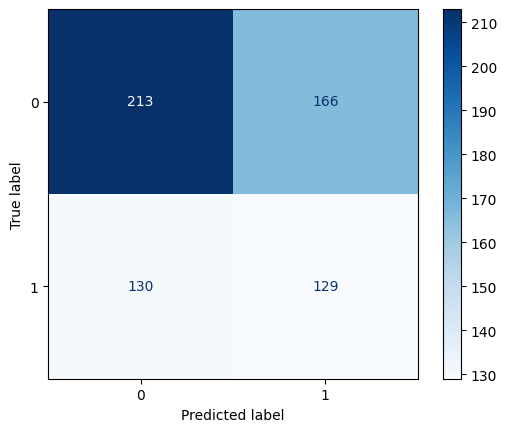

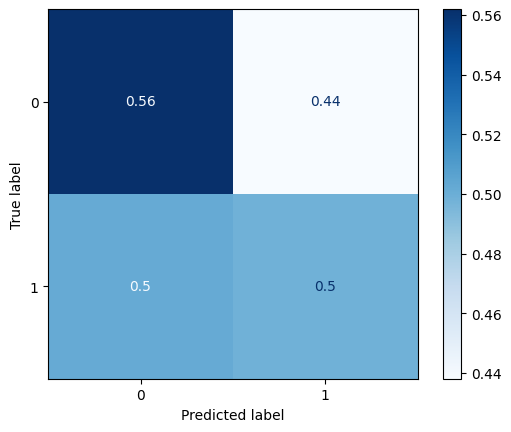

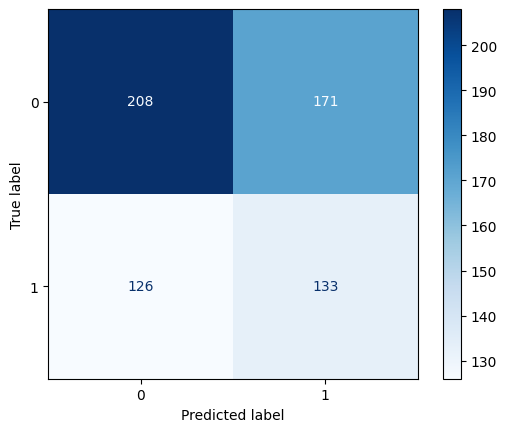

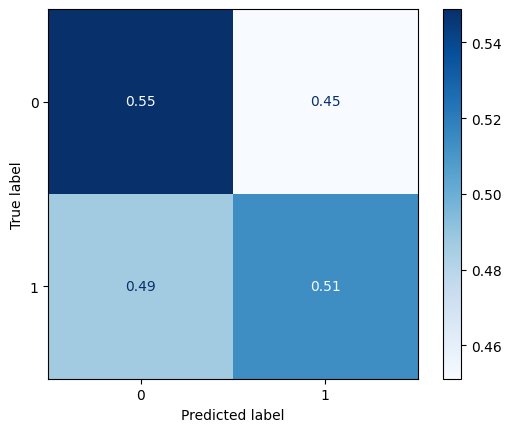

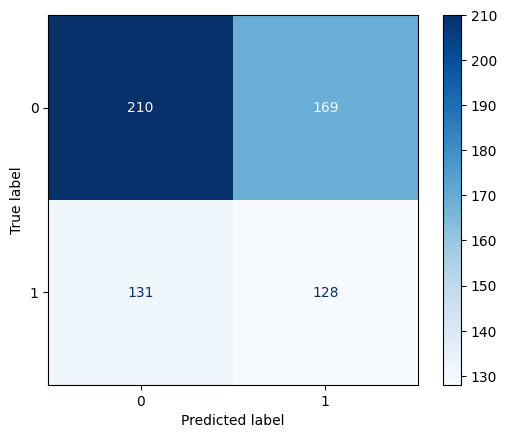

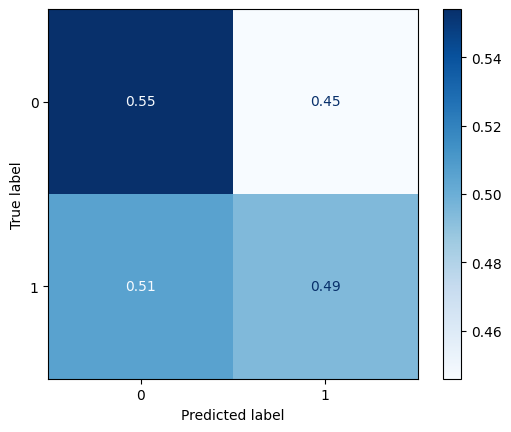

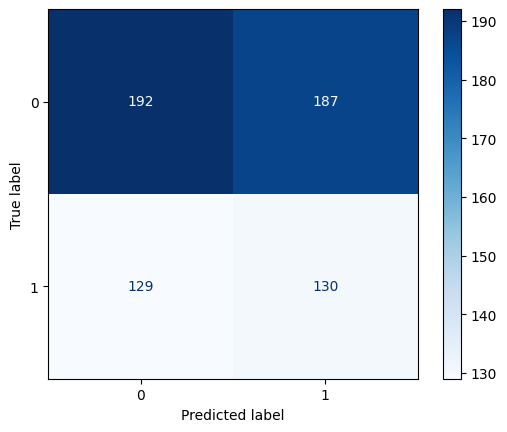

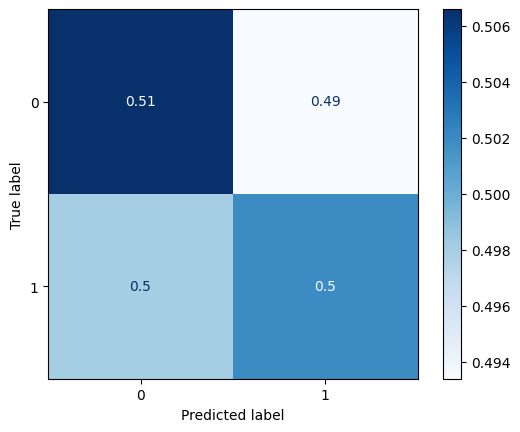

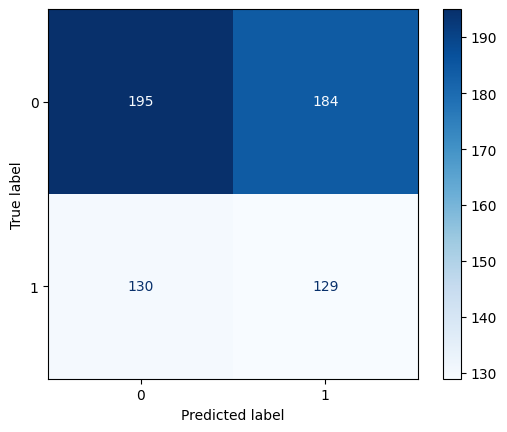

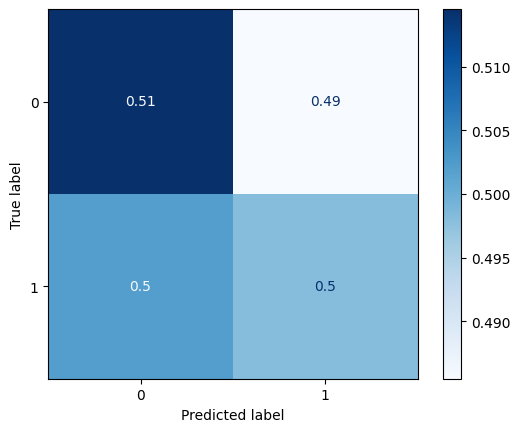

In [48]:
var = '3x3_kernel_64_64_filters_dropout_0.3_balanced_dataset_38_pixels_95_1000'
results_path = '../results/CNN/' + var
os.makedirs(results_path)

for split_i in range(0, 5):
    print(f'Reading training and validation sets in fold {split_i}...')
    
    # Model
    model = help_funcs.CNN_1(out_1 = 64, kernel_cnn_1 = 3, out_2 = 64, kernel_cnn_2 = 3, p=0.3, h = IMAGE_SIZE, w = IMAGE_SIZE)
    model = model.to(DEVICE)

    # Optimizer
    optimizer = torch.optim.AdamW(model.parameters(), lr = LR, weight_decay = WEIGHT_DECAY)

    # Criterion
    criterion = nn.BCELoss()

    # Create dataset objects
    train_dataset = help_funcs.trace(f'{DATASET_PATH}/fold_{split_i}/train', transform=transform)
    validation_dataset = help_funcs.trace(f'{DATASET_PATH}/fold_{split_i}/validation', transform=transform)
    test_dataset = help_funcs.trace(f'{DATASET_PATH}/fold_{split_i}/test', transform=transform)

    # Create data loaders
    train_loader = DataLoader(dataset=train_dataset, batch_size=32, shuffle=True)
    validation_loader = DataLoader(dataset=validation_dataset, batch_size=32)
    test_loader = DataLoader(dataset=test_dataset, batch_size=32)
    
    # Train model
    print(f'Training using fold {split_i}...')
    
    train_loss, val_loss, train_acc, val_acc = help_funcs.train_model(n_epochs = EPOCHS, train_loader = train_loader,
                                                  validation_loader = validation_loader, optimizer = optimizer,
                                                  model = model, criterion = criterion, device = DEVICE)
    
    # Save loss curves
    help_funcs.save_losses(train_loss, val_loss, f'{results_path}/fold_{split_i}_train_val_loss.pdf')
    
    # Save accuracy curves
    help_funcs.save_accuracies(train_acc, val_acc, f'{results_path}/fold_{split_i}_train_val_accuracy.pdf')
    
    # Evaluate test set
    all_preds, all_pred_scores, all_labels = help_funcs.run_predictions(model, test_loader, DEVICE)
    
    # Calculate accuracy
    accuracy = accuracy_score(all_labels, all_preds)

    # Calculate confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1)[:, None]

    # Calculate ROC AUC
    fpr, tpr, _ = roc_curve(all_labels, all_pred_scores)
    auc = roc_auc_score(all_labels, all_pred_scores)
    
    # Save evaluation results
    help_funcs.save_eval_results(f'{results_path}/fold_{split_i}_test_results.txt', split_i, accuracy,
                                 classification_report(all_labels, all_preds, target_names=['0-inactive', '1-active'], digits=3),
                                 cm, cm_norm)

    # Save ROC
    help_funcs.save_roc(fpr, tpr, auc, f'{results_path}/fold_{split_i}_ROC.pdf')

    # Save confusion matrices
    # Confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    disp.figure_.savefig(f'{results_path}/fold_{split_i}_confusion_matrix.pdf', format='pdf')
    
    # Normalized confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm)
    disp.plot(cmap='Blues')
    disp.figure_.savefig(f'{results_path}/fold_{split_i}_confusion_matrix_normalized.pdf', format='pdf')
    

### Testing overfitting

In [11]:
y_pred_all = []
y_pred_score_all = []
label_all = []

model.eval()

with torch.no_grad():
    for imgs, labels in train_loader:
        imgs = imgs.to(DEVICE)
        y_pred_score = model(imgs)
        y_pred = y_pred_score >= 0.5
        y_pred_all.extend(y_pred.long().view(-1).cpu().numpy())
        y_pred_score_all.extend(y_pred_score.view(-1).cpu().numpy())
        label_all.extend(labels.long().view(-1).numpy())

y_pred_all = [int(x) for x in y_pred_all]
y_pred_score_all = [float(x) for x in y_pred_score_all]
label_all = [int(x) for x in label_all]

In [12]:
train_loader

In [13]:
fpr_train, tpr_train, _ = roc_curve(label_all, y_pred_score_all)
auc_train = roc_auc_score(label_all, y_pred_score_all)

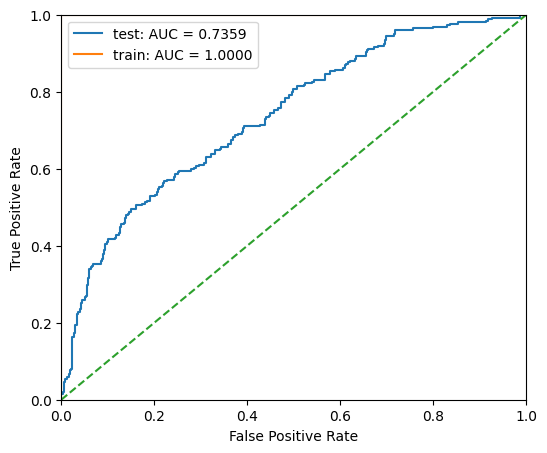

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
ax.plot(fpr, tpr, label=f"test: AUC = {auc:.4f}")
ax.plot(fpr_train, tpr_train, label=f"train: AUC = {auc_train:.4f}")
ax.plot([0, 1], [0, 1], linestyle="--")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")

ax.legend()


#### Identify which tested images are properly classified

In [15]:
test_dataset = help_funcs.trace_with_path(f'{DATASET_PATH}/fold_3/test', transform=transform)
test_loader = DataLoader(dataset=test_dataset, batch_size=32)

In [16]:
y_pred_all = []
y_pred_score_all = []
label_all = []
files_all = []

model.eval()

with torch.no_grad():
    for imgs, labels, files in test_loader:
        imgs = imgs.to(DEVICE)
        y_pred_score = model(imgs)
        y_pred = y_pred_score >= 0.5
        y_pred_all.extend(y_pred.long().view(-1).cpu().numpy())
        y_pred_score_all.extend(y_pred_score.view(-1).cpu().numpy())
        label_all.extend(labels.long().view(-1).numpy())
        files_all.extend(files)

y_pred_all = [int(x) for x in y_pred_all]
y_pred_score_all = [float(x) for x in y_pred_score_all]
label_all = [int(x) for x in label_all]

In [34]:
# Create dataframe with all predictions
import pandas as pd

predictions_df = pd.DataFrame({'file': files_all, 'prediction': y_pred_all, 'label': label_all})

predictions_good_df = predictions_df[predictions_df['prediction'] == predictions_df['label']]
predictions_good_df['structure'] = predictions_good_df['file'].apply(lambda x: x.split('/')[-1].split('_')[1].split('.')[0])

In [39]:
predictions_good_df

,file,prediction,label,structure
0,../data/Su_2020/CNN_splits_balanced_zscore//fo...,0,0,1413
3,../data/Su_2020/CNN_splits_balanced_zscore//fo...,0,0,8379
4,../data/Su_2020/CNN_splits_balanced_zscore//fo...,0,0,1177
7,../data/Su_2020/CNN_splits_balanced_zscore//fo...,0,0,1836
8,../data/Su_2020/CNN_splits_balanced_zscore//fo...,0,0,10542
...,...,...,...,...
627,../data/Su_2020/CNN_splits_balanced_zscore//fo...,1,1,585
629,../data/Su_2020/CNN_splits_balanced_zscore//fo...,1,1,1542
631,../data/Su_2020/CNN_splits_balanced_zscore//fo...,1,1,11862
633,../data/Su_2020/CNN_splits_balanced_zscore//fo...,1,1,8604


In [38]:
predictions_good_df.to_csv('../results/CNN/3x3_kernel_64_64_filters_dropout_0.3_balanced_dataset_38_pixels_redo/good_predictions.tsv', sep='\t', index=False)

## Train DNA MERFISH data (Su et al. 2020) - simulated dataset

### Define model, criterion and optimizers

In [49]:
# Hyperparameters - extracted from best model in Rajpurkar et al. 2021
LR = 0.00001
WEIGHT_DECAY = 0.000005
BATCH_SIZE = 32
EPOCHS = 500
#IMAGE_SIZE = 52
IMAGE_SIZE = 38 # Use original size
DEVICE="mps"

DATASET_PATH = '../data/Su_2020/simulated_dataset/CNN_splits_balanced_95_1000_zscore/'

# Define transform - adapted to image size in Rajpurkar et al. 2021 
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
])

### Train and evaluate on 5 different splits

Reading training and validation sets in fold 0...
Training using fold 0...
Training epoch 25...
Training epoch 50...
Training epoch 75...
Training epoch 100...
Training epoch 125...
Training epoch 150...
Training epoch 175...
Training epoch 200...
Training epoch 225...
Training epoch 250...
Training epoch 275...
Training epoch 300...
Training epoch 325...
Training epoch 350...
Training epoch 375...
Training epoch 400...
Training epoch 425...
Training epoch 450...
Training epoch 475...
Reading training and validation sets in fold 1...
Training using fold 1...
Training epoch 25...
Training epoch 50...
Training epoch 75...
Training epoch 100...
Training epoch 125...
Training epoch 150...
Training epoch 175...
Training epoch 200...
Training epoch 225...
Training epoch 250...
Training epoch 275...
Training epoch 300...
Training epoch 325...
Training epoch 350...
Training epoch 375...
Training epoch 400...
Training epoch 425...
Training epoch 450...
Training epoch 475...
Reading training and

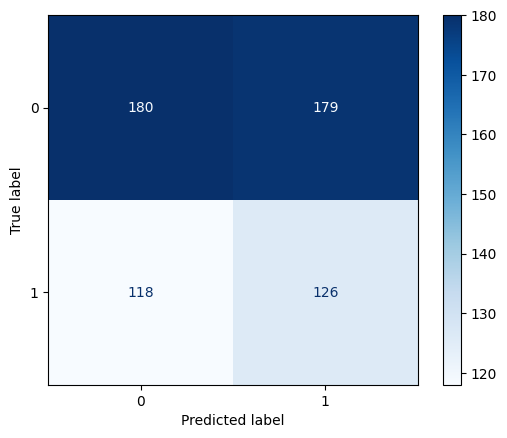

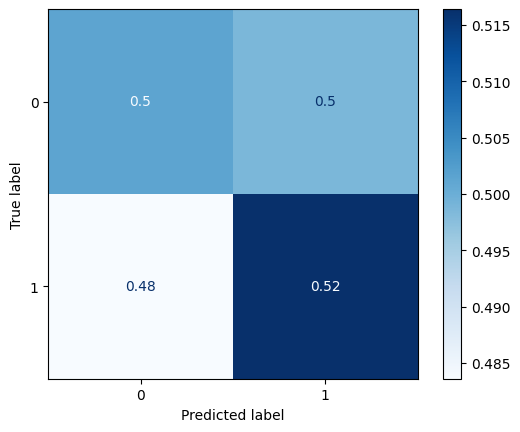

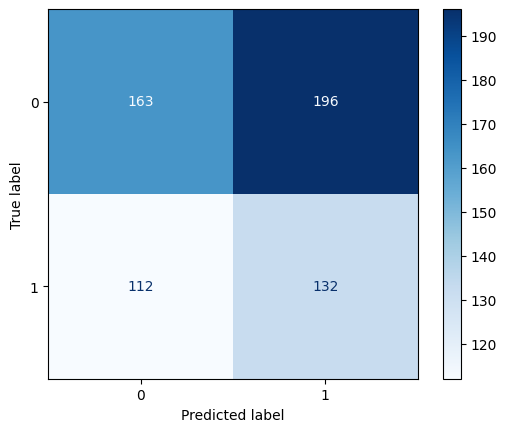

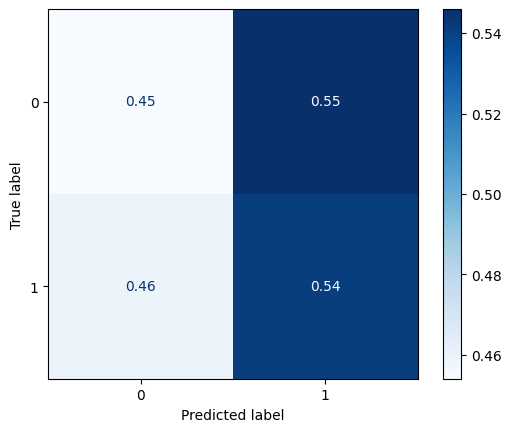

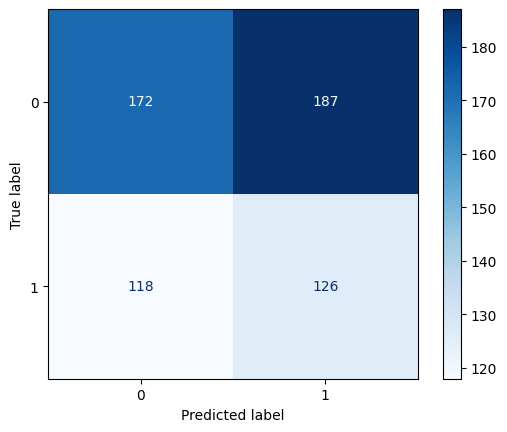

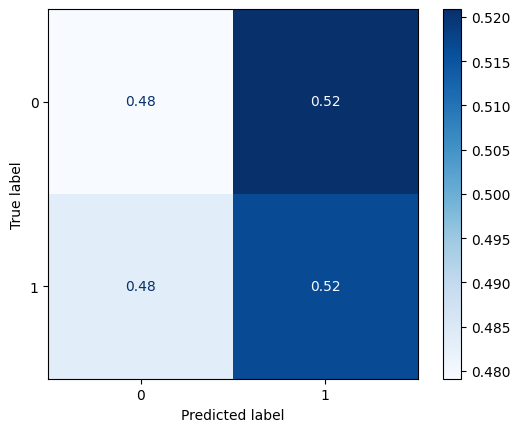

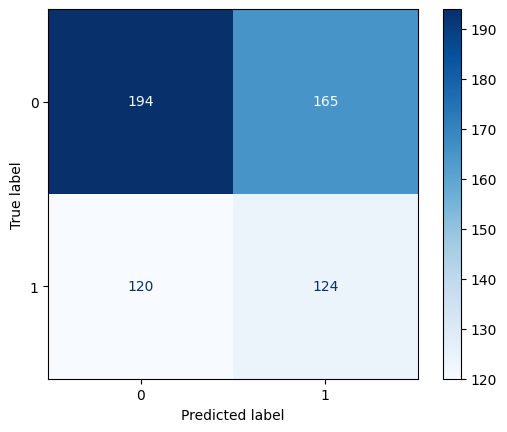

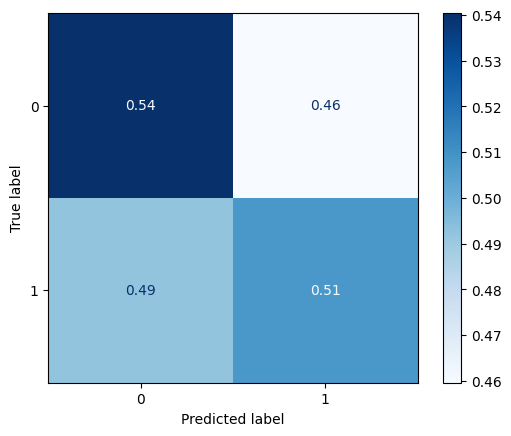

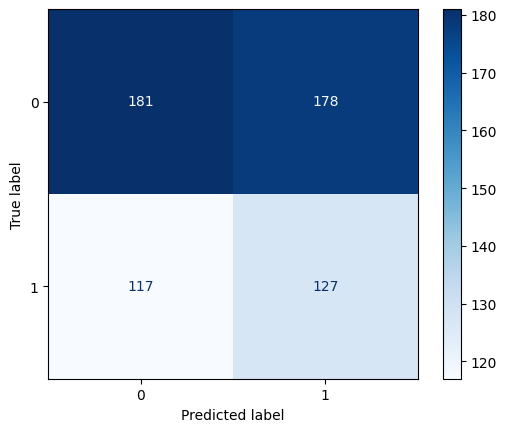

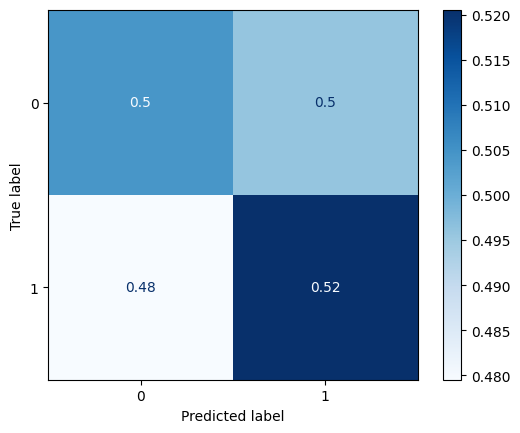

In [50]:
var = '3x3_kernel_64_64_filters_dropout_0.3_balanced_dataset_38_pixels_95_1000_oligomodeling_simulations'
results_path = '../results/CNN/' + var
os.makedirs(results_path)

for split_i in range(0, 5):
    print(f'Reading training and validation sets in fold {split_i}...')
    
    # Model
    model = help_funcs.CNN_1(out_1 = 64, kernel_cnn_1 = 3, out_2 = 64, kernel_cnn_2 = 3, p=0.3, h = IMAGE_SIZE, w = IMAGE_SIZE)
    model = model.to(DEVICE)

    # Optimizer
    optimizer = torch.optim.AdamW(model.parameters(), lr = LR, weight_decay = WEIGHT_DECAY)

    # Criterion
    criterion = nn.BCELoss()

    # Create dataset objects
    train_dataset = help_funcs.trace(f'{DATASET_PATH}/fold_{split_i}/train', transform=transform)
    validation_dataset = help_funcs.trace(f'{DATASET_PATH}/fold_{split_i}/validation', transform=transform)
    test_dataset = help_funcs.trace(f'{DATASET_PATH}/fold_{split_i}/test', transform=transform)

    # Create data loaders
    train_loader = DataLoader(dataset=train_dataset, batch_size=32, shuffle=True)
    validation_loader = DataLoader(dataset=validation_dataset, batch_size=32)
    test_loader = DataLoader(dataset=test_dataset, batch_size=32)
    
    # Train model
    print(f'Training using fold {split_i}...')
    
    train_loss, val_loss, train_acc, val_acc = help_funcs.train_model(n_epochs = EPOCHS, train_loader = train_loader,
                                                  validation_loader = validation_loader, optimizer = optimizer,
                                                  model = model, criterion = criterion, device = DEVICE)
    
    # Save loss curves
    help_funcs.save_losses(train_loss, val_loss, f'{results_path}/fold_{split_i}_train_val_loss.pdf')
    
    # Save accuracy curves
    help_funcs.save_accuracies(train_acc, val_acc, f'{results_path}/fold_{split_i}_train_val_accuracy.pdf')
    
    # Evaluate test set
    all_preds, all_pred_scores, all_labels = help_funcs.run_predictions(model, test_loader, DEVICE)
    
    # Calculate accuracy
    accuracy = accuracy_score(all_labels, all_preds)

    # Calculate confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1)[:, None]

    # Calculate ROC AUC
    fpr, tpr, _ = roc_curve(all_labels, all_pred_scores)
    auc = roc_auc_score(all_labels, all_pred_scores)
    
    # Save evaluation results
    help_funcs.save_eval_results(f'{results_path}/fold_{split_i}_test_results.txt', split_i, accuracy,
                                 classification_report(all_labels, all_preds, target_names=['0-inactive', '1-active'], digits=3),
                                 cm, cm_norm)

    # Save ROC
    help_funcs.save_roc(fpr, tpr, auc, f'{results_path}/fold_{split_i}_ROC.pdf')

    # Save confusion matrices
    # Confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    disp.figure_.savefig(f'{results_path}/fold_{split_i}_confusion_matrix.pdf', format='pdf')
    
    # Normalized confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm)
    disp.plot(cmap='Blues')
    disp.figure_.savefig(f'{results_path}/fold_{split_i}_confusion_matrix_normalized.pdf', format='pdf')
    

### Testing overfitting

In [6]:
y_pred_all = []
y_pred_score_all = []
label_all = []

model.eval()

with torch.no_grad():
    for imgs, labels in train_loader:
        imgs = imgs.to(DEVICE)
        y_pred_score = model(imgs)
        y_pred = y_pred_score >= 0.5
        y_pred_all.extend(y_pred.long().view(-1).cpu().numpy())
        y_pred_score_all.extend(y_pred_score.view(-1).cpu().numpy())
        label_all.extend(labels.long().view(-1).numpy())

y_pred_all = [int(x) for x in y_pred_all]
y_pred_score_all = [float(x) for x in y_pred_score_all]
label_all = [int(x) for x in label_all]

In [7]:
fpr_train, tpr_train, _ = roc_curve(label_all, y_pred_score_all)
auc_train = roc_auc_score(label_all, y_pred_score_all)

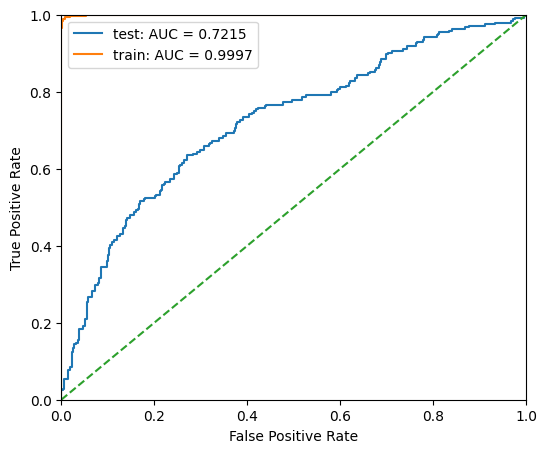

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
ax.plot(fpr, tpr, label=f"test: AUC = {auc:.4f}")
ax.plot(fpr_train, tpr_train, label=f"train: AUC = {auc_train:.4f}")
ax.plot([0, 1], [0, 1], linestyle="--")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")

ax.legend()


## Train ORCA data (Mateo et al. 2019)

### Define model, criterion and optimizers

In [2]:
# Hyperparameters - extracted from best model in Rajpurkar et al. 2021
LR = 0.00001
WEIGHT_DECAY = 0.000005
BATCH_SIZE = 32
EPOCHS = 500
IMAGE_SIZE = 52
DEVICE="mps"

DATASET_PATH = '../data/Mateo_2019/CNN_splits_balanced_75_250_filtered_zscore/'

# Define transform - adapted to image size in Rajpurkar et al. 2021 
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
])

### Train and evaluate on 5 different splits

Reading training and validation sets in fold 0...
Training using fold 0...
Training epoch 25...
Training epoch 50...
Training epoch 75...
Training epoch 100...
Training epoch 125...
Training epoch 150...
Training epoch 175...
Training epoch 200...
Training epoch 225...
Training epoch 250...
Training epoch 275...
Training epoch 300...
Training epoch 325...
Training epoch 350...
Training epoch 375...
Training epoch 400...
Training epoch 425...
Training epoch 450...
Training epoch 475...
Reading training and validation sets in fold 1...
Training using fold 1...
Training epoch 25...
Training epoch 50...
Training epoch 75...
Training epoch 100...
Training epoch 125...
Training epoch 150...
Training epoch 175...
Training epoch 200...
Training epoch 225...
Training epoch 250...
Training epoch 275...
Training epoch 300...
Training epoch 325...
Training epoch 350...
Training epoch 375...
Training epoch 400...
Training epoch 425...
Training epoch 450...
Training epoch 475...
Reading training and

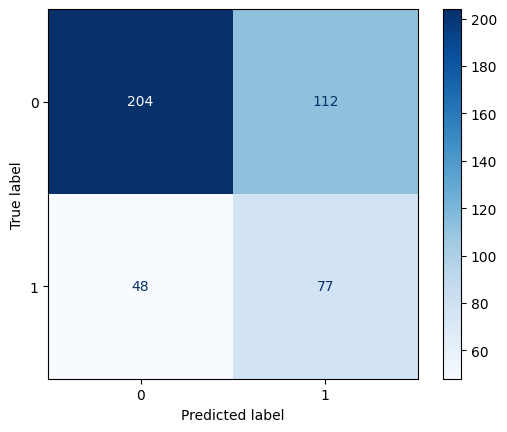

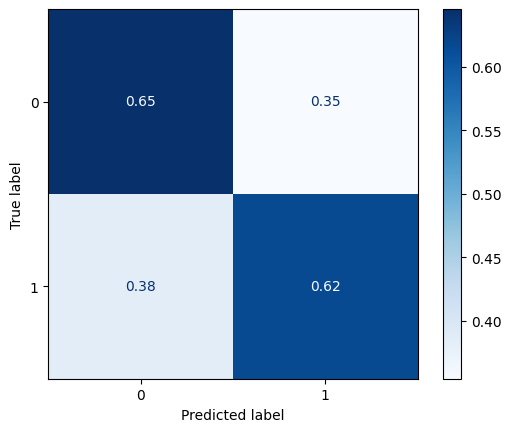

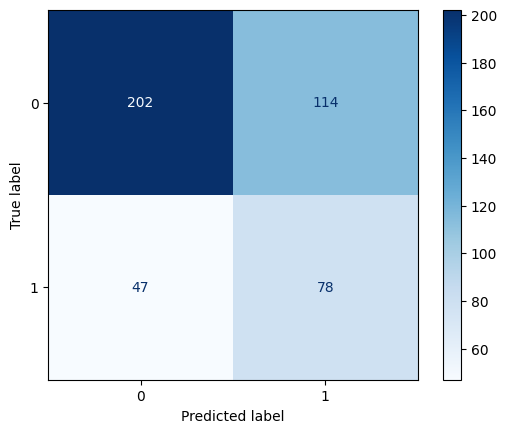

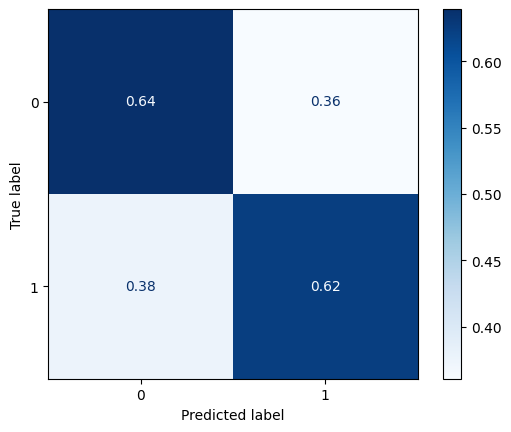

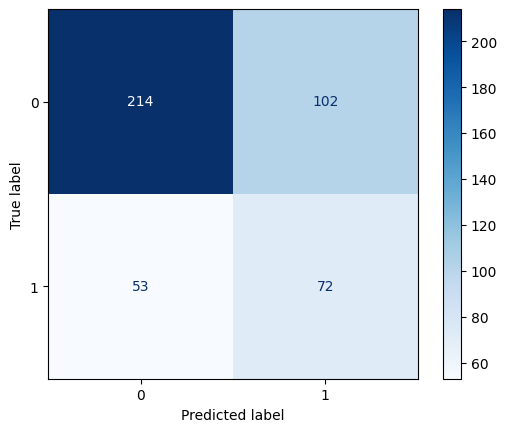

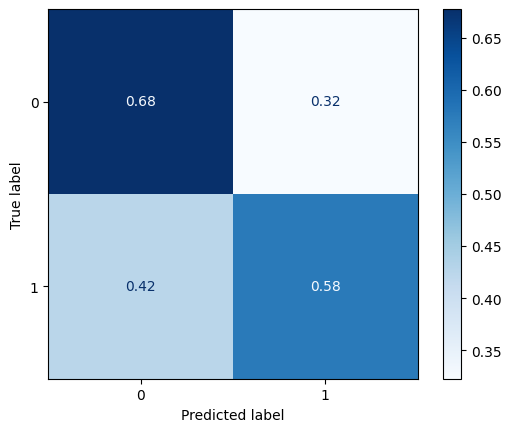

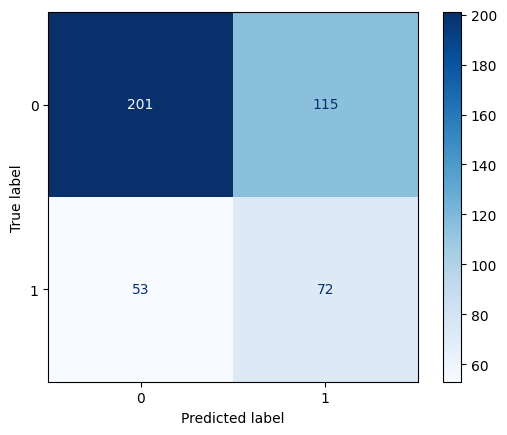

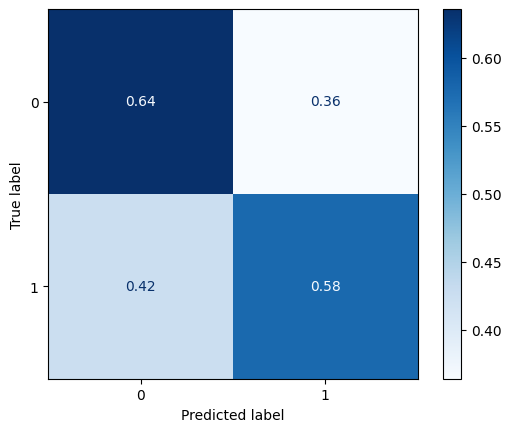

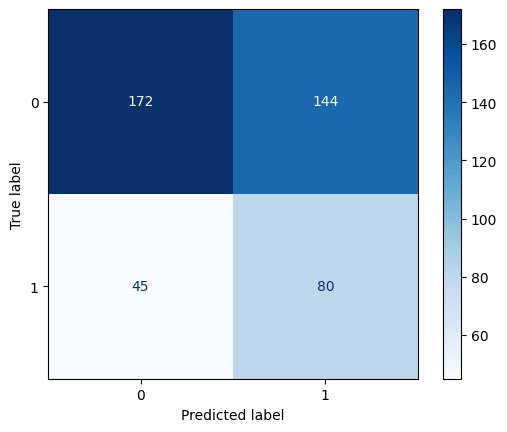

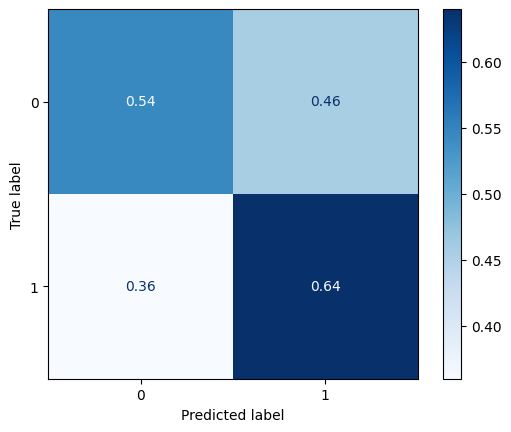

In [7]:
var = '3x3_kernel_64_64_filters_dropout_0.3_balanced_dataset_52_pixels_full_75_250_filtered'
results_path = '../results/CNN_Mateo/' + var
os.makedirs(results_path)

for split_i in range(0, 5):
    print(f'Reading training and validation sets in fold {split_i}...')
    
    # Model
    model = help_funcs.CNN_1(out_1 = 64, kernel_cnn_1 = 3, out_2 = 64, kernel_cnn_2 = 3, p=0.3, h = IMAGE_SIZE, w = IMAGE_SIZE)
    model = model.to(DEVICE)

    # Optimizer
    optimizer = torch.optim.AdamW(model.parameters(), lr = LR, weight_decay = WEIGHT_DECAY)

    # Criterion
    criterion = nn.BCELoss()

    # Create dataset objects
    train_dataset = help_funcs.trace(f'{DATASET_PATH}/fold_{split_i}/train', transform=transform)
    validation_dataset = help_funcs.trace(f'{DATASET_PATH}/fold_{split_i}/validation', transform=transform)
    test_dataset = help_funcs.trace(f'{DATASET_PATH}/fold_{split_i}/test', transform=transform)

    # Create data loaders
    train_loader = DataLoader(dataset=train_dataset, batch_size=32, shuffle=True)
    validation_loader = DataLoader(dataset=validation_dataset, batch_size=32)
    test_loader = DataLoader(dataset=test_dataset, batch_size=32)
    
    # Train model
    print(f'Training using fold {split_i}...')
    
    train_loss, val_loss, train_acc, val_acc = help_funcs.train_model(n_epochs = EPOCHS, train_loader = train_loader,
                                                  validation_loader = validation_loader, optimizer = optimizer,
                                                  model = model, criterion = criterion, device = DEVICE)
    
    # Save loss curves
    help_funcs.save_losses(train_loss, val_loss, f'{results_path}/fold_{split_i}_train_val_loss.pdf')
    
    # Save accuracy curves
    help_funcs.save_accuracies(train_acc, val_acc, f'{results_path}/fold_{split_i}_train_val_accuracy.pdf')
    
    # Evaluate test set
    all_preds, all_pred_scores, all_labels = help_funcs.run_predictions(model, test_loader, DEVICE)
    
    # Calculate accuracy
    accuracy = accuracy_score(all_labels, all_preds)

    # Calculate confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1)[:, None]

    # Calculate ROC AUC
    fpr, tpr, _ = roc_curve(all_labels, all_pred_scores)
    auc = roc_auc_score(all_labels, all_pred_scores)
    
    # Save evaluation results
    help_funcs.save_eval_results(f'{results_path}/fold_{split_i}_test_results.txt', split_i, accuracy,
                                 classification_report(all_labels, all_preds, target_names=['0-inactive', '1-active'], digits=3),
                                 cm, cm_norm)

    # Save ROC
    help_funcs.save_roc(fpr, tpr, auc, f'{results_path}/fold_{split_i}_ROC.pdf')
    roc_df = pd.DataFrame({'fpr': fpr, 'tpr': tpr})
    roc_df.to_csv(f'{results_path}/fold_{split_i}_roc.tsv', sep='\t')

    # Save confusion matrices
    # Confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    disp.figure_.savefig(f'{results_path}/fold_{split_i}_confusion_matrix.pdf', format='pdf')
    
    # Normalized confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm)
    disp.plot(cmap='Blues')
    disp.figure_.savefig(f'{results_path}/fold_{split_i}_confusion_matrix_normalized.pdf', format='pdf')
    

## Train ORCA data (Mateo et al. 2019) - final set

### Define model, criterion and optimizers

In [20]:
# Hyperparameters - extracted from best model in Rajpurkar et al. 2021
LR = 0.00001
WEIGHT_DECAY = 0.000005
BATCH_SIZE = 32
EPOCHS = 500
IMAGE_SIZE = 52
DEVICE="mps"

DATASET_PATH = '../data/Mateo_2019/CNN_splits_balanced_75_5000_filtered_full_shuffled_zscore/'

# Define transform - adapted to image size in Rajpurkar et al. 2021 
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
])

### Train and evaluate on 5 different splits

Training epoch 25...
Training epoch 50...
Training epoch 75...
Training epoch 100...
Training epoch 125...
Training epoch 150...
Training epoch 175...
Training epoch 200...
Training epoch 225...
Training epoch 250...
Training epoch 275...
Training epoch 300...
Training epoch 325...
Training epoch 350...
Training epoch 375...
Training epoch 400...
Training epoch 425...
Training epoch 450...
Training epoch 475...


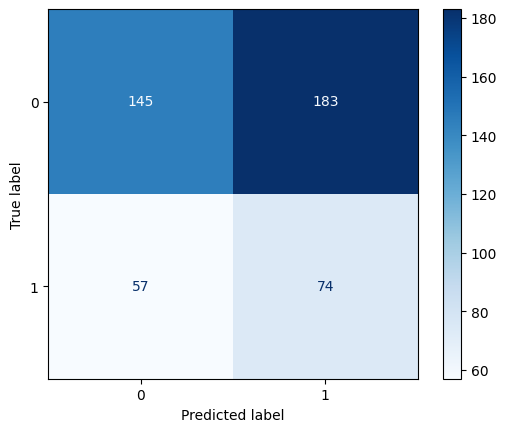

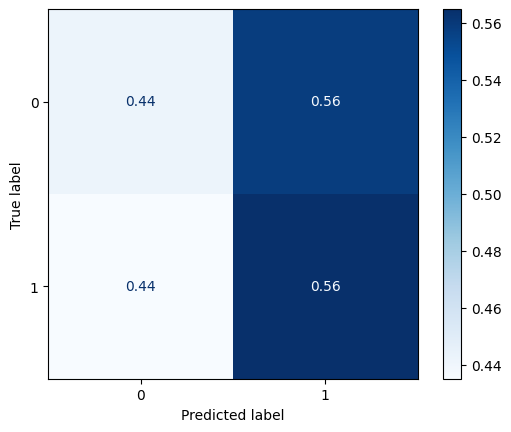

In [ ]:
var = '3x3_kernel_64_64_filters_dropout_0.3_balanced_dataset_52_pixels_full_75_5000_filtered_final_shuffled'
results_path = '../results/CNN_Mateo/' + var
os.makedirs(results_path)

# Model
model = help_funcs.CNN_1(out_1 = 64, kernel_cnn_1 = 3, out_2 = 64, kernel_cnn_2 = 3, p=0.3, h = IMAGE_SIZE, w = IMAGE_SIZE)
model = model.to(DEVICE)

# Optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr = LR, weight_decay = WEIGHT_DECAY)

# Criterion
criterion = nn.BCELoss()

# Create dataset objects
train_dataset = help_funcs.trace(f'{DATASET_PATH}/train', transform=transform)
test_dataset = help_funcs.trace(f'{DATASET_PATH}/test', transform=transform)

# Create data loaders
train_loader = DataLoader(dataset=train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=32)

# Train model
train_loss, val_loss, train_acc, val_acc = help_funcs.train_model(n_epochs = EPOCHS, train_loader = train_loader,
                                                validation_loader = test_loader, optimizer = optimizer,
                                                model = model, criterion = criterion, device = DEVICE)

# Save loss curves
help_funcs.save_losses(train_loss, val_loss, f'{results_path}/train_val_loss.pdf')

# Save accuracy curves
help_funcs.save_accuracies(train_acc, val_acc, f'{results_path}/train_val_accuracy.pdf')

# Evaluate test set
all_preds, all_pred_scores, all_labels = help_funcs.run_predictions(model, test_loader, DEVICE)

# Calculate accuracy
accuracy = accuracy_score(all_labels, all_preds)

# Calculate confusion matrix
cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1)[:, None]

# Calculate ROC AUC
fpr, tpr, _ = roc_curve(all_labels, all_pred_scores)
auc = roc_auc_score(all_labels, all_pred_scores)

# Save evaluation results
help_funcs.save_eval_results(f'{results_path}/test_results.txt', '---', accuracy,
                                classification_report(all_labels, all_preds, target_names=['0-inactive', '1-active'], digits=3),
                                cm, cm_norm)

# Save ROC
help_funcs.save_roc(fpr, tpr, auc, f'{results_path}/ROC.pdf')
roc_df = pd.DataFrame({'fpr': fpr, 'tpr': tpr})
roc_df.to_csv(f'{results_path}/roc.tsv', sep='\t')

# Save confusion matrices
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
disp.figure_.savefig(f'{results_path}/confusion_matrix.pdf', format='pdf')

# Normalized confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm)
disp.plot(cmap='Blues')
disp.figure_.savefig(f'{results_path}/confusion_matrix_normalized.pdf', format='pdf')
    

## Train ORCA data (Mateo et al. 2019) - simulated dataset

### Define model, criterion and optimizers

In [15]:
# Hyperparameters - extracted from best model in Rajpurkar et al. 2021
LR = 0.00001
WEIGHT_DECAY = 0.000005
BATCH_SIZE = 32
EPOCHS = 500
IMAGE_SIZE = 52
DEVICE="mps"

DATASET_PATH = '../data/Mateo_2019/simulated_dataset/CNN_splits_balanced_75_5000_full_zscore/'

# Define transform - adapted to image size in Rajpurkar et al. 2021 
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
])

### Train and evaluate on 5 different splits

Training using fold 0...
Training epoch 25...
Training epoch 50...
Training epoch 75...
Training epoch 100...
Training epoch 125...
Training epoch 150...
Training epoch 175...
Training epoch 200...
Training epoch 225...
Training epoch 250...
Training epoch 275...
Training epoch 300...
Training epoch 325...
Training epoch 350...
Training epoch 375...
Training epoch 400...
Training epoch 425...
Training epoch 450...
Training epoch 475...


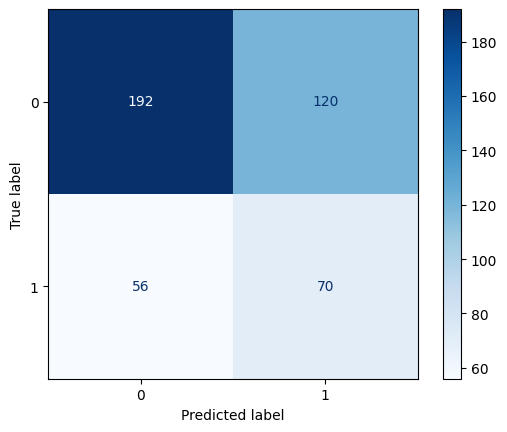

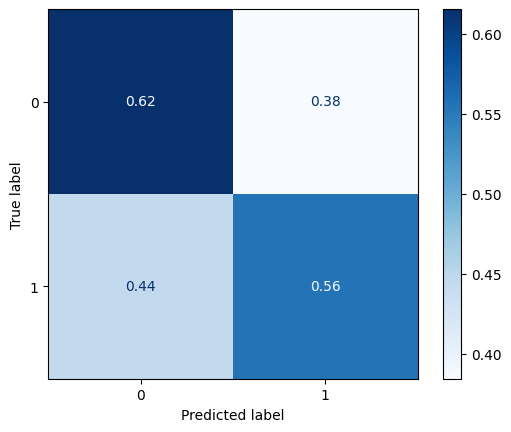

In [18]:
var = '3x3_kernel_64_64_filters_dropout_0.3_balanced_dataset_52_pixels_full_75_5000_full_filtered_oligomodeling_simulations'
results_path = '../results/CNN_Mateo/' + var
os.makedirs(results_path)

# Model
model = help_funcs.CNN_1(out_1 = 64, kernel_cnn_1 = 3, out_2 = 64, kernel_cnn_2 = 3, p=0.3, h = IMAGE_SIZE, w = IMAGE_SIZE)
model = model.to(DEVICE)

# Optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr = LR, weight_decay = WEIGHT_DECAY)

# Criterion
criterion = nn.BCELoss()

# Create dataset objects
train_dataset = help_funcs.trace(f'{DATASET_PATH}/train', transform=transform)
test_dataset = help_funcs.trace(f'{DATASET_PATH}/test', transform=transform)

# Create data loaders
train_loader = DataLoader(dataset=train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=32)

# Train model 
train_loss, val_loss, train_acc, val_acc = help_funcs.train_model(n_epochs = EPOCHS, train_loader = train_loader,
                                                validation_loader = test_loader, optimizer = optimizer,
                                                model = model, criterion = criterion, device = DEVICE)

# Save loss curves
help_funcs.save_losses(train_loss, val_loss, f'{results_path}/train_val_loss.pdf')

# Save accuracy curves
help_funcs.save_accuracies(train_acc, val_acc, f'{results_path}/train_val_accuracy.pdf')

# Evaluate test set
all_preds, all_pred_scores, all_labels = help_funcs.run_predictions(model, test_loader, DEVICE)

# Calculate accuracy
accuracy = accuracy_score(all_labels, all_preds)

# Calculate confusion matrix
cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1)[:, None]

# Calculate ROC AUC
fpr, tpr, _ = roc_curve(all_labels, all_pred_scores)
auc = roc_auc_score(all_labels, all_pred_scores)

# Save evaluation results
help_funcs.save_eval_results(f'{results_path}/test_results.txt', '---', accuracy,
                                classification_report(all_labels, all_preds, target_names=['0-inactive', '1-active'], digits=3),
                                cm, cm_norm)

# Save ROC
help_funcs.save_roc(fpr, tpr, auc, f'{results_path}/ROC.pdf')
roc_df = pd.DataFrame({'fpr': fpr, 'tpr': tpr})
roc_df.to_csv(f'{results_path}/roc.tsv', sep='\t')

# Save confusion matrices
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
disp.figure_.savefig(f'{results_path}/confusion_matrix.pdf', format='pdf')

# Normalized confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm)
disp.plot(cmap='Blues')
disp.figure_.savefig(f'{results_path}/confusion_matrix_normalized.pdf', format='pdf')
    

### Testing overfitting

In [ ]:
train_dataset.samples

[('../data/Su_2020/simulated_dataset/CNN_splits_balanced_zscore//fold_4/train/inactive/structure_1350328.tsv',
  0),
 ('../data/Su_2020/simulated_dataset/CNN_splits_balanced_zscore//fold_4/train/inactive/structure_807291.tsv',
  0),
 ('../data/Su_2020/simulated_dataset/CNN_splits_balanced_zscore//fold_4/train/inactive/structure_1090177.tsv',
  0),
 ('../data/Su_2020/simulated_dataset/CNN_splits_balanced_zscore//fold_4/train/inactive/structure_752662.tsv',
  0),
 ('../data/Su_2020/simulated_dataset/CNN_splits_balanced_zscore//fold_4/train/inactive/structure_1047388.tsv',
  0),
 ('../data/Su_2020/simulated_dataset/CNN_splits_balanced_zscore//fold_4/train/inactive/structure_772001.tsv',
  0),
 ('../data/Su_2020/simulated_dataset/CNN_splits_balanced_zscore//fold_4/train/inactive/structure_546254.tsv',
  0),
 ('../data/Su_2020/simulated_dataset/CNN_splits_balanced_zscore//fold_4/train/inactive/structure_973672.tsv',
  0),
 ('../data/Su_2020/simulated_dataset/CNN_splits_balanced_zscore//fold

In [ ]:
img

tensor([[[-1.9194, -0.6035,  0.4945,  ...,  0.8990,  1.0395,  0.7482],
         [-0.6035, -1.9194, -0.8201,  ...,  0.1924,  0.5770,  0.1509],
         [ 0.4945, -0.8201, -1.9194,  ...,  0.1409,  0.6947,  0.2251],
         ...,
         [ 0.8990,  0.1924,  0.1409,  ..., -1.9194, -1.3195, -1.6354],
         [ 1.0395,  0.5770,  0.6947,  ..., -1.3195, -1.9194, -1.4163],
         [ 0.7482,  0.1509,  0.2251,  ..., -1.6354, -1.4163, -1.9194]]])

In [ ]:
label

tensor([0.])

In [ ]:
y_pred_all = []
y_pred_score_all = []
label_all = []

model.eval()

with torch.no_grad():
    for imgs, labels in train_loader:
        imgs = imgs.to(DEVICE)
        y_pred_score = model(imgs)
        y_pred = y_pred_score >= 0.5
        y_pred_all.extend(y_pred.long().view(-1).cpu().numpy())
        y_pred_score_all.extend(y_pred_score.view(-1).cpu().numpy())
        label_all.extend(labels.long().view(-1).numpy())

y_pred_all = [int(x) for x in y_pred_all]
y_pred_score_all = [float(x) for x in y_pred_score_all]
label_all = [int(x) for x in label_all]

In [ ]:
fpr_train, tpr_train, _ = roc_curve(label_all, y_pred_score_all)
auc_train = roc_auc_score(label_all, y_pred_score_all)

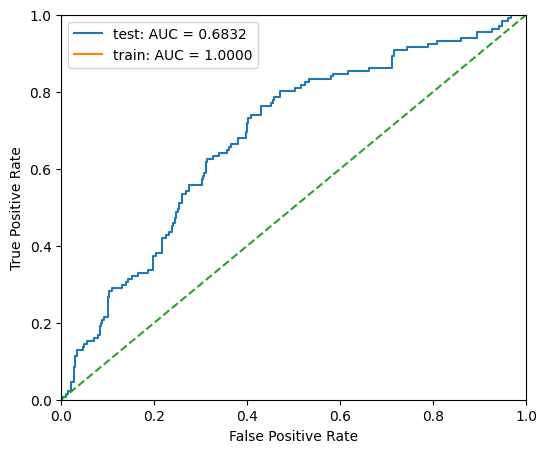

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
ax.plot(fpr, tpr, label=f"test: AUC = {auc:.4f}")
ax.plot(fpr_train, tpr_train, label=f"train: AUC = {auc_train:.4f}")
ax.plot([0, 1], [0, 1], linestyle="--")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")

ax.legend()


#### Extremely high overfitting, as training AUC is 1.00 and the test one much lower